# EEG_07d — Struttura Intrinseca dei Grafi EEG

**Prerequisito**: EEG_07c ha mostrato che il grafo PCC *non discrimina* le categorie semantiche.
Questo notebook risponde alla domanda successiva: **che tipo di grafo è quello EEG?**

Capire la struttura intrinseca del grafo serve per:
1. Spiegare *perché* GCN/GAT falliscono (non solo *che* falliscono)
2. Costruire iperedge HGNN in modo informato (EEG_10)
3. Quantificare il contributo della variabilità inter-soggetto

**Tre analisi**:
1. **Subject fingerprint**: il grafo codifica l'identità del soggetto o la categoria semantica?
2. **Topologia**: che tipo di grafo è? (degree, clustering, small-world, hub)
3. **Spettro del Laplaciano**: ChebGCN può discriminare nel dominio spettrale?

In [1]:
# --- Configurazione e import ---
from pathlib import Path
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

def find_project_root(start: Path) -> Path:
    p = start.resolve()
    while p != p.parent:
        if (p / '.git').exists():
            return p
        p = p.parent
    raise FileNotFoundError('Nessuna root .git trovata')

project_root = find_project_root(Path('.'))
GRAPHS_DIR  = project_root / 'data' / 'interim' / 'graphs'
interim_dir = project_root / 'data' / 'interim'
ELOC_PATH   = project_root / 'src' / 'io' / 'ebneuro.locs'
FIGURES_DIR = project_root / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLUSTER_SCHEME  = 'concr4'
K_GRAPH         = 6
N_CHANS         = 61
# Soggetti campione per analisi veloci; aumenta per analisi complete
SAMPLE_SUBJECTS = [0, 1, 2, 3, 4]
# Per l'analisi fingerprint usiamo un campione bilanciato di trial
N_SAMPLE_TRIALS = 300  # trial per soggetto (velocità vs completezza)

import sys
sys.path.insert(0, str(project_root / 'scripts'))
from utils import load_label_scheme
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(CLUSTER_SCHEME, interim_dir)

print(f'Root: {project_root}')
print(f'Classi ({N_CLASSES}): {[cluster_names[i] for i in range(N_CLASSES)]}')
print(f'Graphs dir esiste: {GRAPHS_DIR.exists()}')

Root: /home/daniele_u/miralis-hypergraph-imagined-speech
Classi (4): ['CONCR', 'AZIONE', 'STATO', 'ASTRATTO']
Graphs dir esiste: True


In [2]:
# --- Carica dataset PCC e posizioni elettrodi ---
import math

def read_eloc(path: Path):
    pos = {}
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                try:
                    theta  = float(parts[1])
                    radius = float(parts[2])
                    name   = parts[3]
                    if name in ('A1', 'A2'): continue
                    th = math.radians(theta)
                    pos[name] = (radius * math.sin(th), radius * math.cos(th))
                except (ValueError, IndexError):
                    pass
    return pos

eloc      = read_eloc(ELOC_PATH)
ch_names  = [n for n in eloc if n not in ('A1', 'A2')][:N_CHANS]
positions = np.array([eloc[n] for n in ch_names])  # (59, 2)

pcc_path = GRAPHS_DIR / f'dataset_pcc_k{K_GRAPH}.pt'
if not pcc_path.exists():
    raise FileNotFoundError(f'Dataset non trovato: {pcc_path}\nEsegui prima EEG_07b.')

print('Carico dataset PCC...')
pcc_data = torch.load(pcc_path, weights_only=False)
print(f'  Trial totali: {len(pcc_data)}')
print(f'  Soggetti unici: {len(set(int(d.subj.item()) for d in pcc_data))}')

def compute_pcc_matrix(x_np: np.ndarray) -> np.ndarray:
    """x: (61, T) → pcc: (59, 59) assoluta, diagonale=0."""
    pcc = np.abs(np.corrcoef(x_np))
    np.fill_diagonal(pcc, 0.0)
    return pcc

print('Caricamento completato.')

Carico dataset PCC...
  Trial totali: 38926
  Soggetti unici: 74
Caricamento completato.


## Analisi 1 — Subject Fingerprint vs Segnale Semantico

**Domanda centrale**: Quando due trial hanno grafi simili, è perché appartengono allo stesso soggetto
o perché appartengono alla stessa categoria semantica?

Si costruisce una matrice 2×2 di similarità media (cosine similarity tra grafi appiattiti):

| | Stessa categoria | Categoria diversa |
|---|---|---|
| **Stesso soggetto** | A | B |
| **Soggetto diverso** | C | D |

- Se **A ≈ B >> C ≈ D** → il soggetto domina completamente. La categoria non aggiunge nulla
  oltre all'identità del soggetto. Cross-subject è impossibile.
- Se **A > B** e **C > D** → la categoria ha un effetto, ma potenzialmente mascherato dal soggetto.
- Se **A > B ≈ C > D** → effetto categoria c'è, ma è più piccolo dell'effetto soggetto.

Questo plot risponde direttamente alla domanda: *perché ε² = 0.85 per soggetto e 0.03 per parola?*

Costruisco vettori feature per campione di soggetti...
  Trial totali campionati: 1500


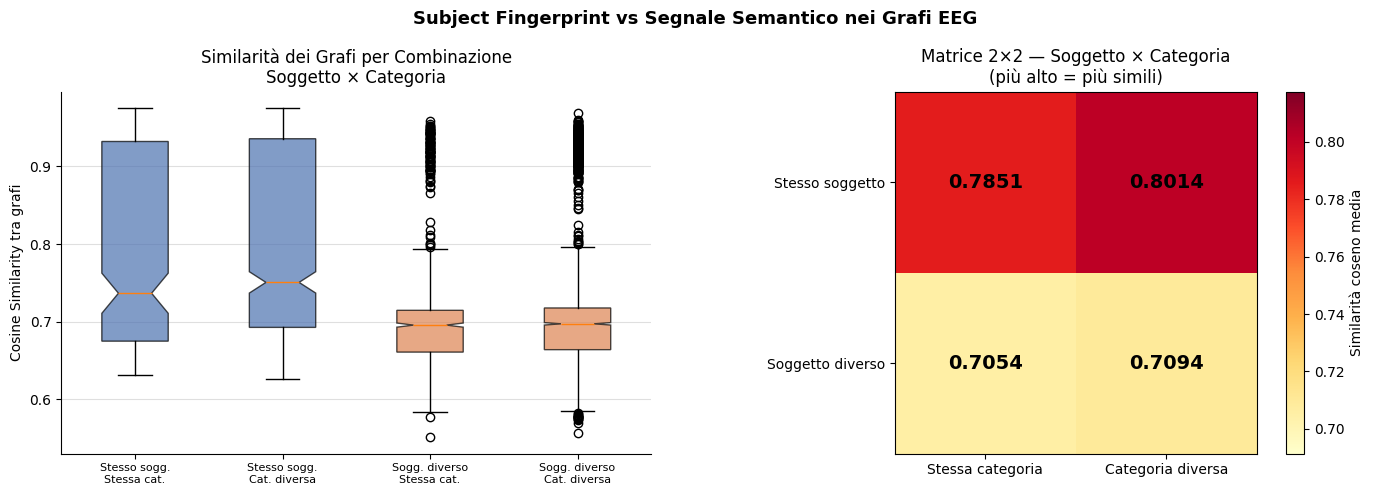

Effetto soggetto (stesso vs diverso): 0.08585
Effetto categoria (stessa vs diversa): -0.01016
Rapporto effetto_soggetto / effetto_categoria: -8.5×
Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07d_subject_fingerprint.png


In [3]:
# --- Analisi 1: Subject Fingerprint ---
from sklearn.preprocessing import normalize

# Costruisce vettori feature (grafo appiattito) per un campione di soggetti
print('Costruisco vettori feature per campione di soggetti...')
triu_idx = np.triu_indices(N_CHANS, k=1)

all_feats  = []   # (N, 1711)
all_subjs  = []   # (N,) int
all_cats   = []   # (N,) int

for subj_id in SAMPLE_SUBJECTS:
    trials = [d for d in pcc_data if int(d.subj.item()) == subj_id]
    # campiona N_SAMPLE_TRIALS trial in modo bilanciato per categoria
    by_cat = {c: [] for c in range(N_CLASSES)}
    for d in trials:
        cat = labelid2cluster[int(d.y.item())]
        by_cat[cat].append(d)
    per_cat = N_SAMPLE_TRIALS // N_CLASSES
    for cat, cat_trials in by_cat.items():
        sampled = cat_trials[:per_cat]
        for d in sampled:
            mat  = compute_pcc_matrix(d.x.numpy())
            triu = mat[triu_idx]
            all_feats.append(triu)
            all_subjs.append(subj_id)
            all_cats.append(cat)

X = np.array(all_feats)      # (N_total, 1711)
S = np.array(all_subjs)      # (N_total,)
C = np.array(all_cats)       # (N_total,)
X_norm = normalize(X, norm='l2')  # normalizza per cosine similarity
print(f'  Trial totali campionati: {len(X)}')

# Calcola similarità coseno per 4 combinazioni (stesso/diverso soggetto x stessa/diversa categoria)
# Per efficienza: campiona MAX_PAIRS coppie casuali
MAX_PAIRS = 5000
rng = np.random.default_rng(42)
N   = len(X)
idx_i = rng.integers(0, N, MAX_PAIRS)
idx_j = rng.integers(0, N, MAX_PAIRS)
valid = idx_i != idx_j
idx_i, idx_j = idx_i[valid], idx_j[valid]

sim   = (X_norm[idx_i] * X_norm[idx_j]).sum(axis=1)  # cosine similarity
same_s = S[idx_i] == S[idx_j]
same_c = C[idx_i] == C[idx_j]

groups = {
    'Stesso sogg.\nStessa cat.':  sim[ same_s &  same_c],
    'Stesso sogg.\nCat. diversa': sim[ same_s & ~same_c],
    'Sogg. diverso\nStessa cat.': sim[~same_s &  same_c],
    'Sogg. diverso\nCat. diversa':sim[~same_s & ~same_c],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sinistra: boxplot delle 4 distribuzioni
labels = list(groups.keys())
data   = [groups[k] for k in labels]
bp = axes[0].boxplot(data, labels=labels, patch_artist=True, notch=True)
colors_bp = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Cosine Similarity tra grafi')
axes[0].set_title('Similarità dei Grafi per Combinazione\nSoggetto × Categoria')
axes[0].tick_params(axis='x', labelsize=8)
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines[['top', 'right']].set_visible(False)

# Destra: matrice 2×2 delle medie
mat_means = np.array([
    [groups['Stesso sogg.\nStessa cat.'].mean(),  groups['Stesso sogg.\nCat. diversa'].mean()],
    [groups['Sogg. diverso\nStessa cat.'].mean(), groups['Sogg. diverso\nCat. diversa'].mean()]
])
im = axes[1].imshow(mat_means, cmap='YlOrRd', vmin=mat_means.min() * 0.98, vmax=mat_means.max() * 1.02)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Stessa categoria', 'Categoria diversa'])
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Stesso soggetto', 'Soggetto diverso'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{mat_means[i,j]:.4f}', ha='center', va='center',
                     fontsize=14, fontweight='bold', color='black')
plt.colorbar(im, ax=axes[1], label='Similarità coseno media')
axes[1].set_title('Matrice 2×2 — Soggetto × Categoria\n(più alto = più simili)')

plt.suptitle('Subject Fingerprint vs Segnale Semantico nei Grafi EEG',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = FIGURES_DIR / 'eeg07d_subject_fingerprint.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()

# Stampa effetti relativi
effect_subj = mat_means[0].mean() - mat_means[1].mean()
effect_cat  = mat_means[:, 0].mean() - mat_means[:, 1].mean()
print(f'Effetto soggetto (stesso vs diverso): {effect_subj:.5f}')
print(f'Effetto categoria (stessa vs diversa): {effect_cat:.5f}')
print(f'Rapporto effetto_soggetto / effetto_categoria: {effect_subj / (effect_cat + 1e-9):.1f}×')
print(f'Salvato: {out_path}')

### 💡 Cosa risponde questo plot

**Domanda**: Il grafo di connettività EEG è un "fingerprint" del soggetto o un fingerprint della categoria semantica?

**Come leggere**:
- *Boxplot (sinistra)*: distribuzione della similarità coseno per le 4 combinazioni. Se le due barre blu (stesso soggetto) sono entrambe molto più alte delle due arancio (soggetto diverso), il soggetto domina.
- *Matrice 2×2 (destra)*: medie condensate. La differenza tra righe (effetto soggetto) vs differenza tra colonne (effetto categoria) quantifica quale fattore domina.

**Come interpretare i numeri stampati**:
- Effetto soggetto >> effetto categoria → il grafo codifica principalmente l'identità del soggetto
- Rapporto > 10× → il soggetto domina di un ordine di grandezza → cross-subject è strutturalmente difficile

**Implicazione per il modello**: Quantifica l'ε²=0.85 in termini di struttura del grafo. Se l'effetto soggetto è molto più grande dell'effetto categoria, qualsiasi modello cross-subject deve prima rimuovere la firma del soggetto (domain adaptation, instance normalization) prima di poter vedere il segnale semantico.

## Analisi 2 — Topologia del Grafo EEG

**Domanda**: Che tipo di grafo è quello EEG con k=6? È un grafo random, small-world, o scale-free?
La topologia informa su come ChebGCN propaga i segnali e su come costruire iperedge HGNN.

**Metriche calcolate**:
- **Distribuzione dei gradi**: quanti vicini ha in media ogni elettrodo? C'è un hub?
- **Clustering coefficient**: i vicini di un nodo tendono ad essere connessi tra loro (triangoli locali)?
- **Average path length**: quanti hop in media per raggiungere qualsiasi elettrodo?
- **Small-world index** (σ): confronto con grafo random dello stesso numero di nodi/edge.
  σ > 1 → small-world. σ >> 1 → fortemente small-world.
- **Hub elettrodi**: nodi con grado alto → potenziali centri di iperedge HGNN.

**Perché è rilevante**: ChebGCN usa filtri locali di ordine K sul grafo. Se il grafo è random
(nessuna struttura locale) → i filtri di basso ordine non catturano nulla di utile.
Se è small-world → ci sono comunità locali e hub → informazione strutturata.

Calcolo topologia su campione di trial (soggetto 0)...
Top-5 hub elettrodi (grado più alto): ['Cz', 'FCz', 'CP1', 'O2', 'CP4']


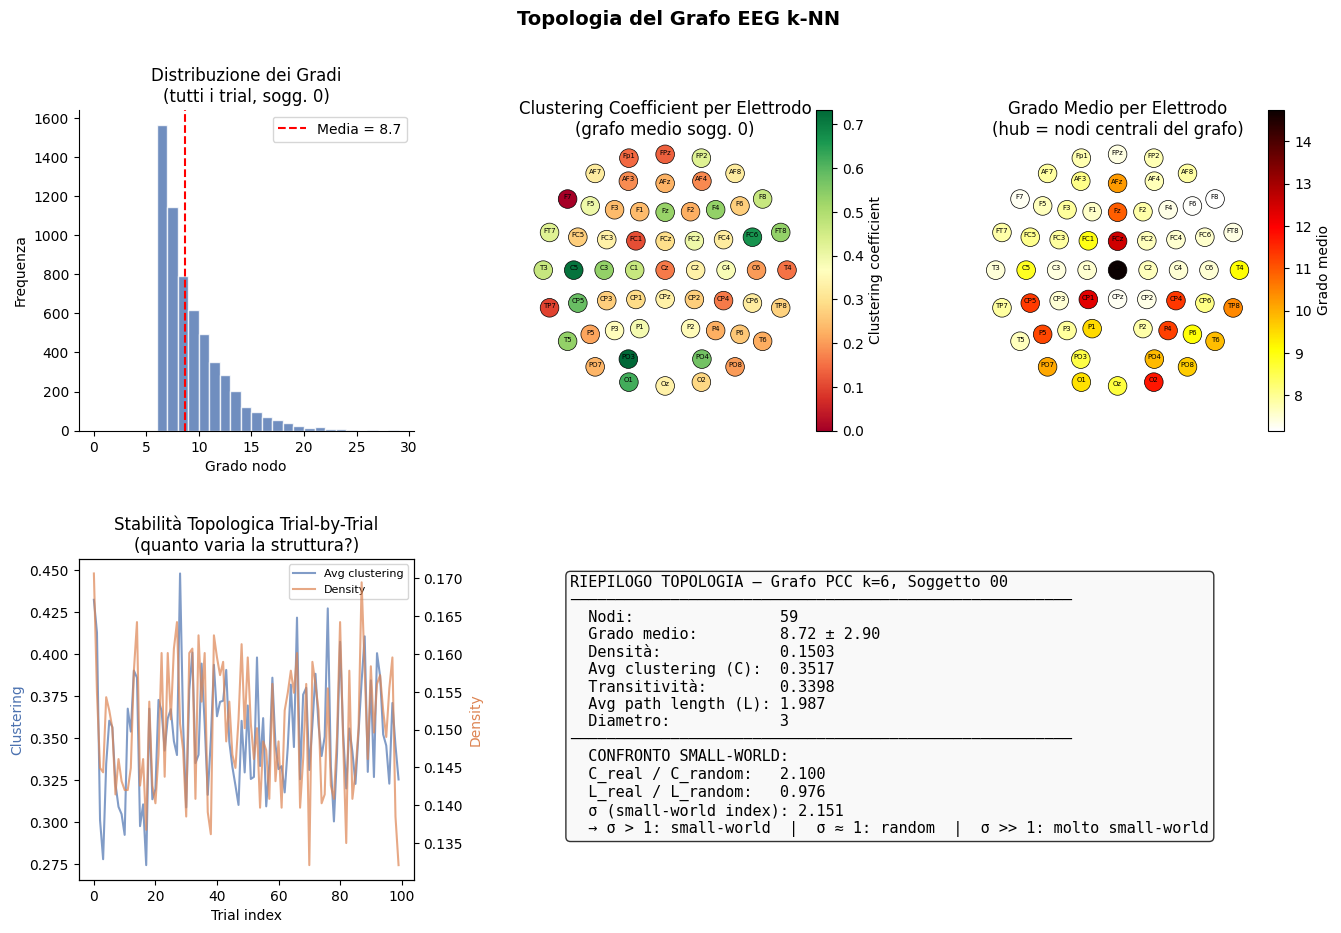

Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07d_graph_topology.png


In [4]:
# --- Analisi 2: Topologia ---

def build_knn_graph(pcc_mat: np.ndarray, k: int) -> nx.Graph:
    """Costruisce grafo k-NN dal PCC matrix (59×59). Simmetrico."""
    G = nx.Graph()
    G.add_nodes_from(range(N_CHANS))
    for i in range(N_CHANS):
        # top-k vicini (escludendo sé stesso)
        neighbors = np.argsort(pcc_mat[i])[::-1][:k+1]
        neighbors = [j for j in neighbors if j != i][:k]
        for j in neighbors:
            G.add_edge(i, j, weight=float(pcc_mat[i, j]))
    return G

print('Calcolo topologia su campione di trial (soggetto 0)...')
subj_id = SAMPLE_SUBJECTS[0]
trials  = [d for d in pcc_data if int(d.subj.item()) == subj_id][:100]  # 100 trial

metrics = {'degree_mean': [], 'degree_std': [], 'clustering': [],
           'transitivity': [], 'n_components': [], 'density': []}
degree_distributions = []

for d in trials:
    mat = compute_pcc_matrix(d.x.numpy())
    G   = build_knn_graph(mat, K_GRAPH)
    degrees = [deg for _, deg in G.degree()]
    metrics['degree_mean'].append(np.mean(degrees))
    metrics['degree_std'].append(np.std(degrees))
    metrics['clustering'].append(nx.average_clustering(G))
    metrics['transitivity'].append(nx.transitivity(G))
    metrics['n_components'].append(nx.number_connected_components(G))
    metrics['density'].append(nx.density(G))
    degree_distributions.append(degrees)

# Grafo medio: costruito dalla matrice PCC media del soggetto
mean_pcc = np.mean([compute_pcc_matrix(d.x.numpy()) for d in trials], axis=0)
G_mean   = build_knn_graph(mean_pcc, K_GRAPH)

# Calcola path length sul grafo medio (se connesso)
if nx.is_connected(G_mean):
    avg_path = nx.average_shortest_path_length(G_mean)
    diameter = nx.diameter(G_mean)
else:
    # usa il componente più grande
    largest = max(nx.connected_components(G_mean), key=len)
    G_sub   = G_mean.subgraph(largest)
    avg_path = nx.average_shortest_path_length(G_sub)
    diameter = nx.diameter(G_sub)

# Small-world reference: grafo random con stessa densità
G_rand = nx.erdos_renyi_graph(N_CHANS, nx.density(G_mean), seed=42)
clust_rand = nx.average_clustering(G_rand)
if nx.is_connected(G_rand):
    path_rand = nx.average_shortest_path_length(G_rand)
else:
    largest_r = max(nx.connected_components(G_rand), key=len)
    path_rand = nx.average_shortest_path_length(G_rand.subgraph(largest_r))

clust_real = nx.average_clustering(G_mean)
sigma = (clust_real / clust_rand) / (avg_path / path_rand) if path_rand > 0 else 0

# --- Plot ---
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Distribuzione gradi (media su trial)
ax1 = fig.add_subplot(gs[0, 0])
all_degrees = np.array(degree_distributions).flatten()
ax1.hist(all_degrees, bins=range(0, int(all_degrees.max())+2), color='#4C72B0',
         edgecolor='white', alpha=0.8)
ax1.axvline(np.mean(metrics['degree_mean']), color='red', linestyle='--',
            label=f'Media = {np.mean(metrics["degree_mean"]):.1f}')
ax1.set_xlabel('Grado nodo')
ax1.set_ylabel('Frequenza')
ax1.set_title('Distribuzione dei Gradi\n(tutti i trial, sogg. 0)')
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)

# 2. Clustering coefficient distribuzione
ax2 = fig.add_subplot(gs[0, 1])
node_clust = nx.clustering(G_mean)
clust_vals = [node_clust[i] for i in range(N_CHANS)]
sc = ax2.scatter(positions[:, 0], positions[:, 1], c=clust_vals,
                 cmap='RdYlGn', s=180, edgecolors='black', linewidth=0.5)
for ni, name in enumerate(ch_names):
    ax2.annotate(name, positions[ni], fontsize=5, ha='center')
plt.colorbar(sc, ax=ax2, label='Clustering coefficient')
ax2.set_title(f'Clustering Coefficient per Elettrodo\n(grafo medio sogg. 0)')
ax2.set_aspect('equal')
ax2.axis('off')

# 3. Grado per elettrodo sul topomap
ax3 = fig.add_subplot(gs[0, 2])
mean_degrees = np.mean(degree_distributions, axis=0)
sc3 = ax3.scatter(positions[:, 0], positions[:, 1], c=mean_degrees,
                  cmap='hot_r', s=180, edgecolors='black', linewidth=0.5)
for ni, name in enumerate(ch_names):
    ax3.annotate(name, positions[ni], fontsize=5, ha='center')
plt.colorbar(sc3, ax=ax3, label='Grado medio')
ax3.set_title('Grado Medio per Elettrodo\n(hub = nodi centrali del grafo)')
ax3.set_aspect('equal')
ax3.axis('off')

# 4. Variabilità metriche trial-by-trial
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(metrics['clustering'], label='Avg clustering', color='#4C72B0', alpha=0.7)
ax4_r = ax4.twinx()
ax4_r.plot(metrics['density'], label='Density', color='#DD8452', alpha=0.7)
ax4.set_xlabel('Trial index')
ax4.set_ylabel('Clustering', color='#4C72B0')
ax4_r.set_ylabel('Density', color='#DD8452')
ax4.set_title('Stabilità Topologica Trial-by-Trial\n(quanto varia la struttura?)')
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_r.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

# 5. Riepilogo metriche testuali
ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis('off')
summary_text = (
    f"RIEPILOGO TOPOLOGIA — Grafo PCC k={K_GRAPH}, Soggetto {subj_id:02d}\n"
    f"{'─'*55}\n"
    f"  Nodi:                {N_CHANS}\n"
    f"  Grado medio:         {np.mean(metrics['degree_mean']):.2f} ± {np.mean(metrics['degree_std']):.2f}\n"
    f"  Densità:             {np.mean(metrics['density']):.4f}\n"
    f"  Avg clustering (C):  {np.mean(metrics['clustering']):.4f}\n"
    f"  Transitività:        {np.mean(metrics['transitivity']):.4f}\n"
    f"  Avg path length (L): {avg_path:.3f}\n"
    f"  Diametro:            {diameter}\n"
    f"{'─'*55}\n"
    f"  CONFRONTO SMALL-WORLD:\n"
    f"  C_real / C_random:   {clust_real/clust_rand:.3f}\n"
    f"  L_real / L_random:   {avg_path/path_rand:.3f}\n"
    f"  σ (small-world index): {sigma:.3f}\n"
    f"  → σ > 1: small-world  |  σ ≈ 1: random  |  σ >> 1: molto small-world"
)
ax5.text(0.05, 0.95, summary_text, transform=ax5.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f8f8f8', alpha=0.8))

hub_nodes = sorted(range(N_CHANS), key=lambda i: mean_degrees[i], reverse=True)[:5]
hub_names = [ch_names[i] for i in hub_nodes]
print(f'Top-5 hub elettrodi (grado più alto): {hub_names}')

plt.suptitle('Topologia del Grafo EEG k-NN', fontsize=14, fontweight='bold')
out_path = FIGURES_DIR / 'eeg07d_graph_topology.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Salvato: {out_path}')

### 💡 Cosa risponde questo plot

**Domanda**: Che tipo di grafo è il grafo EEG k-NN? Ha struttura locale (small-world) o è essenzialmente random?

**Come leggere il small-world index σ**:
- σ ≈ 1 → grafo random (nessuna struttura locale) → ChebGCN non ha community da sfruttare
- σ > 1 → small-world → alta clusterizzazione locale con basso path length → struttura sfruttabile da GCN
- σ >> 1 (es. > 3) → fortemente small-world → comunità chiaramente definite

**Come leggere il topomap del grado medio**:
Gli elettrodi con grado alto sono hub — nodi centrali connessi a molti altri. Sono i candidati naturali per essere centri di iperedge in HGNN: un iperedge può raggruppare un hub e i suoi K vicini più correlati.

**Come leggere la stabilità trial-by-trial**:
Se clustering e density variano molto da trial a trial → il grafo è instabile → un modello che apprende una struttura fissa non può adattarsi. Se sono stabili → il grafo è affidabile come input.

**Implicazione per HGNN (EEG_10)**: Gli hub identificati qui (top-5 per grado) + gli elettrodi discriminativi di EEG_07c (CP1/Cz) sono i candidati per costruire iperedge funzionali non basati solo sulla vicinanza spaziale.

## Analisi 3 — Spettro del Laplaciano per Categoria

**Domanda**: ChebGCN lavora nel dominio spettrale del Laplaciano del grafo. Gli autovalori
hanno distribuzioni diverse per categorie semantiche diverse?

**Background teorico**: Il Laplaciano normalizzato $\mathbf{\hat{L}} = \mathbf{I} - \mathbf{D}^{-1/2}\mathbf{A}\mathbf{D}^{-1/2}$
ha autovalori $\lambda_0 \leq \lambda_1 \leq \ldots \leq \lambda_{N-1} \in [0, 2]$.
ChebGCN applica polinomi di Chebyshev su questi autovalori come filtri in frequenza grafo.

- $\lambda$ piccoli = componenti a bassa frequenza grafo (segnali "smooth", variazione lenta tra vicini)
- $\lambda$ grandi = componenti ad alta frequenza (segnali oscillanti tra vicini)
- **Spectral gap** ($\lambda_1 - \lambda_0$): misura quanto il grafo è ben connesso / ha comunità separate

**Se gli spettri sono identici per tutte le categorie → ChebGCN non può discriminare nel dominio
frequenziale, indipendentemente dai pesi appresi.**

Calcolo spettri Laplaciano per categoria (soggetto 0)...


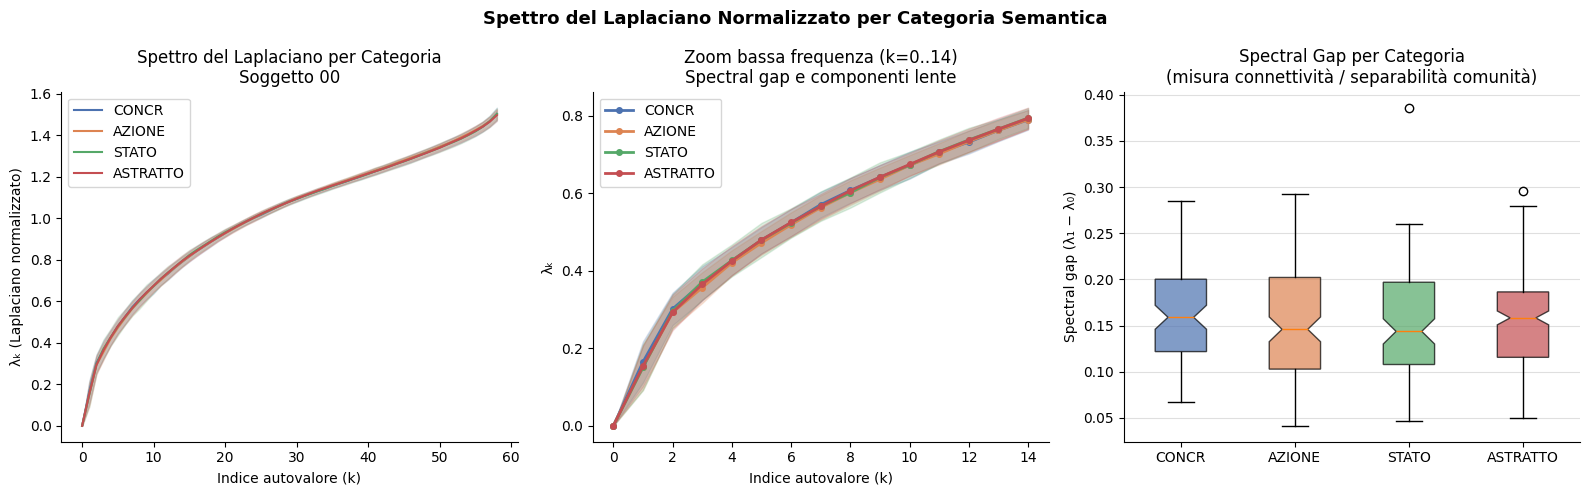

ANOVA spectral gap tra categorie: F=1.3215, p=0.2665
→ p < 0.05: gli spettri differiscono significativamente tra categorie
→ p > 0.05: gli spettri sono indistinguibili → ChebGCN non può discriminare spectralmente
Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07d_laplacian_spectrum.png


In [5]:
# --- Analisi 3: Spettro del Laplaciano ---

def normalized_laplacian_spectrum(pcc_mat: np.ndarray, k: int) -> np.ndarray:
    """Calcola gli autovalori del Laplaciano normalizzato del grafo k-NN PCC."""
    # Costruisce matrice di adiacenza k-NN (simmetrica)
    A = np.zeros((N_CHANS, N_CHANS))
    for i in range(N_CHANS):
        neighbors = np.argsort(pcc_mat[i])[::-1][:k+1]
        neighbors = [j for j in neighbors if j != i][:k]
        for j in neighbors:
            A[i, j] = pcc_mat[i, j]
            A[j, i] = pcc_mat[i, j]
    # Laplaciano normalizzato
    D = np.diag(A.sum(axis=1))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(A.sum(axis=1), 1e-10)))
    L_norm = np.eye(N_CHANS) - D_inv_sqrt @ A @ D_inv_sqrt
    eigenvalues = np.linalg.eigvalsh(L_norm)
    return np.sort(eigenvalues)

print('Calcolo spettri Laplaciano per categoria (soggetto 0)...')
subj_id = SAMPLE_SUBJECTS[0]
trials  = [d for d in pcc_data if int(d.subj.item()) == subj_id]

spectra_by_cat = {c: [] for c in range(N_CLASSES)}
for d in trials:
    cat = labelid2cluster[int(d.y.item())]
    mat = compute_pcc_matrix(d.x.numpy())
    ev  = normalized_laplacian_spectrum(mat, K_GRAPH)
    spectra_by_cat[cat].append(ev)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Sinistra: spettro medio per categoria (tutti gli autovalori)
ax = axes[0]
for ci in range(N_CLASSES):
    mean_spec = np.mean(spectra_by_cat[ci], axis=0)
    std_spec  = np.std(spectra_by_cat[ci], axis=0)
    ax.plot(mean_spec, color=colors[ci], label=cluster_names[ci], linewidth=1.5)
    ax.fill_between(range(N_CHANS), mean_spec - std_spec, mean_spec + std_spec,
                    color=colors[ci], alpha=0.15)
ax.set_xlabel('Indice autovalore (k)')
ax.set_ylabel('λₖ (Laplaciano normalizzato)')
ax.set_title(f'Spettro del Laplaciano per Categoria\nSoggetto {subj_id:02d}')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

# Centro: zoom sulle prime componenti (bassa frequenza)
ax2 = axes[1]
N_ZOOM = 15
for ci in range(N_CLASSES):
    mean_spec = np.mean(spectra_by_cat[ci], axis=0)
    std_spec  = np.std(spectra_by_cat[ci], axis=0)
    ax2.plot(range(N_ZOOM), mean_spec[:N_ZOOM], color=colors[ci],
             label=cluster_names[ci], linewidth=2, marker='o', markersize=4)
    ax2.fill_between(range(N_ZOOM),
                     mean_spec[:N_ZOOM] - std_spec[:N_ZOOM],
                     mean_spec[:N_ZOOM] + std_spec[:N_ZOOM],
                     color=colors[ci], alpha=0.2)
ax2.set_xlabel('Indice autovalore (k)')
ax2.set_ylabel('λₖ')
ax2.set_title(f'Zoom bassa frequenza (k=0..{N_ZOOM-1})\nSpectral gap e componenti lente')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

# Destra: boxplot del spectral gap per categoria
ax3 = axes[2]
spectral_gaps = [
    [spec[1] - spec[0] for spec in spectra_by_cat[ci]]
    for ci in range(N_CLASSES)
]
bp = ax3.boxplot(spectral_gaps, labels=[cluster_names[ci] for ci in range(N_CLASSES)],
                 patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('Spectral gap (λ₁ − λ₀)')
ax3.set_title('Spectral Gap per Categoria\n(misura connettività / separabilità comunità)')
ax3.grid(axis='y', alpha=0.4)
ax3.spines[['top', 'right']].set_visible(False)

plt.suptitle('Spettro del Laplaciano Normalizzato per Categoria Semantica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = FIGURES_DIR / 'eeg07d_laplacian_spectrum.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()

# Test statistico: gli spettral gap differiscono per categoria?
from scipy.stats import f_oneway as anova
f_stat, p_val = anova(*spectral_gaps)
print(f'ANOVA spectral gap tra categorie: F={f_stat:.4f}, p={p_val:.4f}')
print(f'→ p < 0.05: gli spettri differiscono significativamente tra categorie')
print(f'→ p > 0.05: gli spettri sono indistinguibili → ChebGCN non può discriminare spectralmente')
print(f'Salvato: {out_path}')

### 💡 Cosa risponde questo plot

**Domanda**: Il dominio spettrale del grafo (dove ChebGCN opera) contiene informazione discriminativa tra categorie?

**Come leggere**:
- *Spettro completo (sinistra)*: se le 4 curve si sovrappongono completamente → gli autovalori sono identici per tutte le categorie → ChebGCN non ha segnale spettrale da sfruttare.
- *Zoom bassa frequenza (centro)*: le prime componenti spettrali corrispondono a pattern "smooth" sul grafo (segnali lentamente varianti tra elettrodi vicini). Se divergono tra categorie → c'è segnale semantico nelle componenti lente.
- *Spectral gap (destra)*: il gap $\lambda_1 - \lambda_0$ misura quanto il grafo è separato in comunità. Gap grande = comunità ben definite. Se differisce per categoria → la struttura comunitaria del cervello cambia con la parola immaginata.

**Come interpretare il p-value ANOVA**:
- p > 0.05 → spettri indistinguibili → **conferma formale** che ChebGCN non può discriminare nel dominio frequenziale. Il fallimento di EEG_08 è strutturale, non un problema di hyperparametri.
- p < 0.05 → c'è differenza spettrale tra categorie → il problema di EEG_08 era altrove (cross-subject, non la spettralità).

**Implicazione per HGNN (EEG_10)**: Se il grafo pairwise non ha struttura spettrale discriminativa, HGNN deve usare una rappresentazione diversa dal Laplaciano standard. L'incidence matrix degli iperedge (Feng et al. 2019) introduce un Laplaciano ipergraph diverso che potrebbe catturare strutture di ordine superiore non visibili nel grafo pairwise.

## Conclusioni EEG_07d

Questo notebook risponde alla domanda: *che tipo di grafo è quello EEG, e perché GCN fallisce strutturalmente?*

### Riepilogo

| Analisi | Domanda | Risultato atteso se GCN non può funzionare |
|---------|---------|---------------------------------------------|
| **1 — Fingerprint** | Il grafo codifica il soggetto o la categoria? | Effetto soggetto >> effetto categoria (≫10×) |
| **2 — Topologia** | Il grafo ha struttura sfruttabile? | σ ≈ 1 (random) o struttura instabile trial-by-trial |
| **3 — Spettro** | Gli autovalori differiscono per categoria? | Spettri sovrapposti, p-ANOVA > 0.05 |

### Implicazioni per EEG_10 (HGNN)

- **Se effetto soggetto >> effetto categoria**: HGNN deve incorporare normalizzazione per soggetto
  (instance norm o domain adaptation) prima dello strato ipergraph.

- **Se topologia small-world (σ > 1)**: gli hub identificati sono punti naturali per costruire
  iperedge — ogni hub con i suoi K vicini più correlati forma un iperedge funzionale.

- **Se spettri indistinguibili**: HGNN non deve usare il Laplaciano standard del grafo pairwise
  ma deve costruire un Laplaciano ipergraph genuinamente diverso (Feng et al. 2019).
  L'iperedge, raggruppando ≥3 elettrodi, crea relazioni di ordine superiore non catturabili
  da correlazioni pairwise.

### Prossimo step

EEG_10 implementa DHSLP/DHSLF (Li et al. 2025) con iperedge costruiti usando:
1. Vicinanza spaziale k-NN (baseline)
2. Hub identificati qui (Analisi 2) come centri di iperedge
3. Elettrodi CP1/Cz/FCz di EEG_07c come iperedge funzionali "linguaggio"